In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pokeml.data.eda_general import get_extremes
df = pd.read_csv('../datasets/pkdx_min.csv')

In [2]:
# Let us start by identifying those pokes with the lowest and greatest values for each rarity. We define first a nice func as:

out_fea=['type_1', 'type_2']

max_min_overall = pd.concat([get_extremes(df, desired_value='total_stats',  out_features=out_fea, rarity =cat) for cat in ['legendary', 'regular']])
max_min_reg_gen = pd.concat([get_extremes(df, desired_value='total_stats', rarity= 'regular', out_features=out_fea, generation = i) for i in range(1,10)])
max_min_legs = pd.concat([get_extremes(df, desired_value='total_stats', rarity= 'legendary', out_features=out_fea, generation = i) for i in range(1,10)])

print('OVERALL ' + '='*55)
print(max_min_overall)
print('REGULAR ' + '='*55)
print(max_min_reg_gen)
print('LEGENDS ' + '='*55)
print(max_min_legs)

OVERALL =======================================================
  extreme        name  total_stats  generation   type_1  type_2
0     min      cosmog          200           7  psychic     NaN
1     max      arceus          720           4   normal     NaN
0     min  wishiwashi          175           7    water     NaN
1     max     slaking          670           3   normal     NaN
REGULAR =======================================================
  extreme        name  total_stats  generation  type_1    type_2
0     min    caterpie          195           1     bug       NaN
1     max   dragonite          600           1  dragon    flying
0     min     sunkern          180           2   grass       NaN
1     max   tyranitar          600           2    rock      dark
0     min     azurill          190           3  normal     fairy
1     max     slaking          670           3  normal       NaN
0     min   kricketot          194           4     bug       NaN
1     max    garchomp          6

In [3]:
# Well, well, well, well! What do we see here! Except Gen 2 and 3, all regular pokes with max total_stats are fucking dragons! Not only that! it seems that the max_stat for regular pokes is cap at 600! While the minimal one has been changing over time, but not much... 

In [4]:
# Here I will draw the histogram the overall distribution of pokes based on their BST. First I design a function to write BST pokemon by intervals

def interval_bst(data, start, interval):
    """
    Basic Func to get the overall BST in intervals
    """

    mask = data[(data['total_stats'] > start) & (data['total_stats'] <= start + interval)]
    count = mask['total_stats'].count()
    return f"{start} - {start + interval}", float(count)

over_dist = {interval_bst(df, 170 + i , 20)[0] : interval_bst(df, 170 + i , 20)[1] for  i in range (0,560,20)}

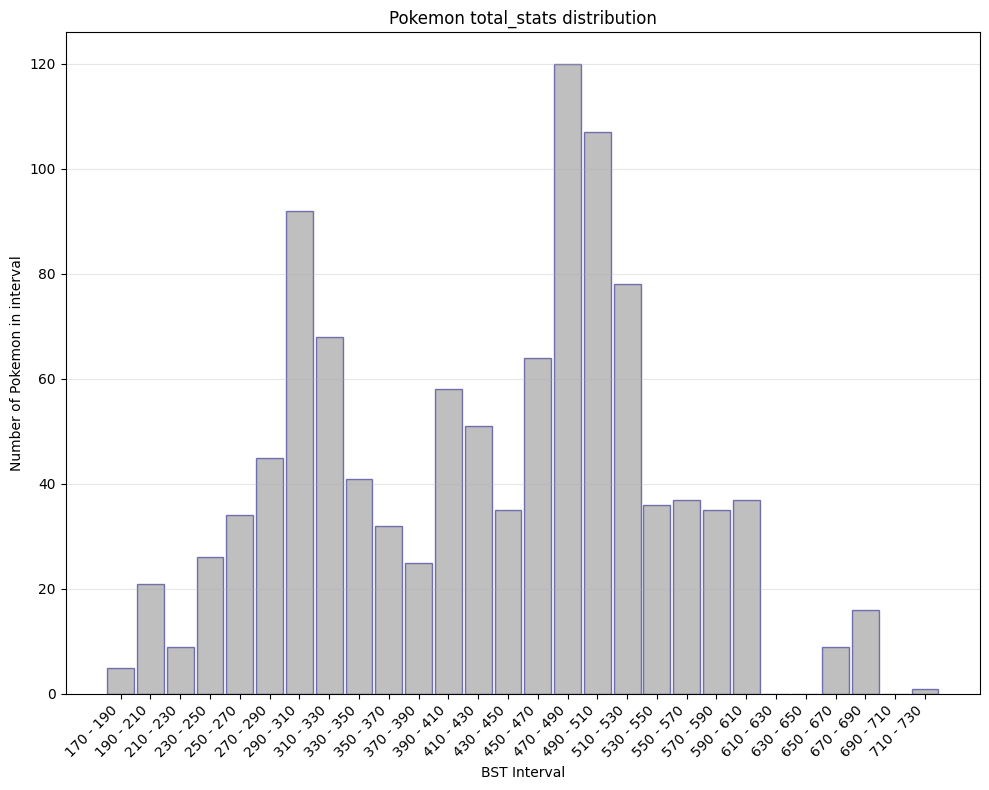

In [6]:
# Then, plot it
plt.figure(figsize=(10, 8))
bins = list(over_dist.keys())
counts = list(over_dist.values())

plt.bar(bins, counts, width=0.9, alpha=0.5, color='grey', edgecolor='navy')
plt.xlabel('BST Interval')
plt.ylabel('Number of Pokemon in interval')
plt.title('Pokemon total_stats distribution')
plt.xticks(rotation=45, ha='right')  # ✅ Fixed rotation
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# We see that majority of pokes cluster by 270-290, which seems to be related to initial stage of evolution chains. But major cluster is by 470-490. Actually, we will see that the total median is 480 BST.

# Not bad, Let us now explore how the median of each generation has changed, together with the overall median and evolution of minima and maxima. 

In [ ]:
# First extract min each gen for regulars, and max for legends:
min_by_gen = max_min_reg_gen[max_min_reg_gen['extreme'] == 'min']['total_stats'].to_list()
max_by_gen = max_min_reg_gen[max_min_reg_gen['extreme'] == 'max']['total_stats'].to_list()
max_overall_legends = max_min_legs[max_min_legs['extreme'] == 'max']['total_stats'].to_list()

# Now, lets get the median for each generation
median_dic = {i: float(df[df['generation'] == i]['total_stats'].median()) for i in range(1,10)}

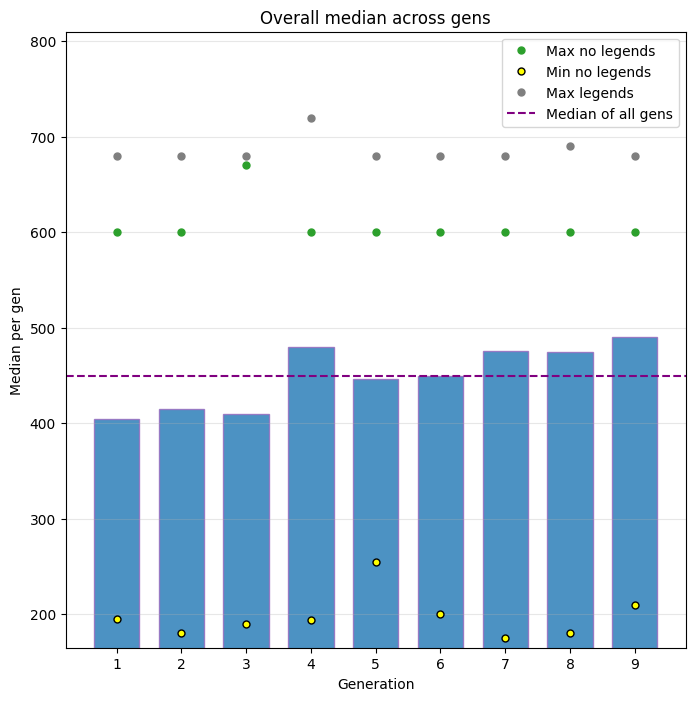

In [ ]:
# Then, plot it
from matplotlib import legend


plt.figure(figsize=(8, 8))
bins = list(range(1,10,1))
counts = list(median_dic.values())

plt.bar(bins, counts, width=0.7, alpha=0.8, color='C0', edgecolor='C4')
plt.plot(bins, max_by_gen, '.', color = 'C2', markersize = 10,label = 'Max no legends')
plt.plot(bins, min_by_gen, '.', color = 'yellow', markersize = 10, markeredgecolor= 'black', label= 'Min no legends')
plt.plot(bins, max_overall_legends, '.', markersize = 10, color = 'C7', label= 'Max legends')
plt.axhline(df['total_stats'].median(), color = 'purple', linestyle='--', label= 'Median of all gens')
plt.xlabel('Generation')
plt.ylabel('Median per gen')
plt.title('Overall median across gens')
plt.xticks(bins) 
plt.grid(True, alpha=0.3, axis='y')
plt.legend(bbox_to_anchor=(1, 1))


plt.ylim(min(min_by_gen)-10, 810)

plt.show()